<a href="https://colab.research.google.com/github/Ashu-42/quant_research_crypto_volatility_forecasting/blob/quant_DL_ashu/notebooks/15min/03_Intraday_Baselines_and_ARCH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03 — Intraday Baselines and ARCH-Family Models

This notebook evaluates simple predictive baselines and three ARCH-family models for the frozen intraday target created in Notebook 02:

\[
RV_{t+1}=r_{t+1}^{2}
\]

where \(r_{t+1}\) is the next candle's close-to-close log return.

## Models

### Baselines
- Persistence
- each rolling-mean-RV feature defined by Notebook 02
- same clock slot on the previous day
- training-only target-slot mean RV

### ARCH family
- GARCH(1,1)
- GJR-GARCH(1,1)
- EGARCH(1,1)

All ARCH models use Student-t innovations and a constant mean.

## Intraday seasonality

The ARCH models are fitted to returns deseasonalized using the **training-only variance seasonality factors** created in Notebook 02.

For clock slot \(s\):

\[
z_t
=
\frac{r_t}{\sqrt{S_s}}
\]

where \(S_s\) is the training-only slot variance factor.

The one-step-ahead forecast is then restored to the original return-variance scale:

\[
\hat{\sigma}_{t+1}^{2}
=
\hat{\sigma}_{z,t+1}^{2}
S_{s(t+1)}.
\]

This prevents the ARCH recursion from having to absorb a deterministic time-of-day volatility pattern.

## Validation policy

- ARCH parameters are fitted on Train only.
- Validation is used for comparison / model selection.
- Test is **not evaluated in this notebook**.
- No missing candles are imputed.

## Interval robustness

All paths, expected row counts, slot counts and time alignment are inferred from the Notebook 02 processing manifest. Changing the upstream experiment from `15m` to `1h` therefore does not require rewriting the modeling logic.

## 1. Imports, package version and Drive

In [1]:
from google.colab import drive

from pathlib import Path
from datetime import datetime, timezone
import importlib.metadata
import importlib.util
import json
import math
import subprocess
import sys
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ARCH_VERSION = "7.2.0"

installed_arch = None

if importlib.util.find_spec("arch") is not None:
    try:
        installed_arch = importlib.metadata.version("arch")
    except Exception:
        installed_arch = None

if installed_arch != ARCH_VERSION:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            f"arch=={ARCH_VERSION}",
        ]
    )

from arch import arch_model

drive.mount("/content/drive")

print(
    "arch version:",
    importlib.metadata.version("arch"),
)

Mounted at /content/drive
arch version: 7.2.0


## 2. Configuration and interval-specific paths

In [2]:
PROJECT_ROOT = Path(
    "/content/drive/MyDrive/Quant Research/15min"
)

# Change this only after the corresponding upstream 01/02
# notebooks have been run for the new interval.
KLINE_INTERVAL = "15m"

SYMBOLS = [
    "BTCUSDT",
    "ETHUSDT",
    "SOLUSDT",
    "XRPUSDT",
]

EPSILON = 1e-12
RETURN_SCALE = 100.0

ARCH_SPECS = {
    "GARCH(1,1)": {
        "vol": "GARCH",
        "p": 1,
        "o": 0,
        "q": 1,
    },

    "GJR-GARCH(1,1)": {
        "vol": "GARCH",
        "p": 1,
        "o": 1,
        "q": 1,
    },

    "EGARCH(1,1)": {
        "vol": "EGARCH",
        "p": 1,
        "o": 1,
        "q": 1,
    },
}

MANIFEST_ROOT = (
    PROJECT_ROOT
    / "manifests"
    / KLINE_INTERVAL
)

RESULTS_ROOT = (
    PROJECT_ROOT
    / "results"
    / KLINE_INTERVAL
)

ARCH_RESULTS_ROOT = (
    RESULTS_ROOT
    / "ARCH"
)

FIGURE_ROOT = (
    ARCH_RESULTS_ROOT
    / "figures"
)

for directory in [
    ARCH_RESULTS_ROOT,
    FIGURE_ROOT,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

print(
    "Project root:",
    PROJECT_ROOT,
)

print(
    "Interval:",
    KLINE_INTERVAL,
)

print(
    "Results:",
    ARCH_RESULTS_ROOT,
)

Project root: /content/drive/MyDrive/Quant Research/15min
Interval: 15m
Results: /content/drive/MyDrive/Quant Research/15min/results/15m/ARCH


## 3. Load Notebook 02 processing manifest and canonical datasets

Paths and feature definitions are read from the manifest rather than duplicated manually.

In [3]:
processing_manifest_candidates = sorted(
    MANIFEST_ROOT.glob(
        f"processing_manifest_{KLINE_INTERVAL}_v*.json"
    )
)

if (
    len(
        processing_manifest_candidates
    )
    != 1
):
    raise FileNotFoundError(
        "Expected exactly one processing manifest for "
        f"{KLINE_INTERVAL}; found "
        f"{len(processing_manifest_candidates)}:\n"
        + "\n".join(
            str(path)
            for path
            in processing_manifest_candidates
        )
    )

PROCESSING_MANIFEST_PATH = (
    processing_manifest_candidates[0]
)

with open(
    PROCESSING_MANIFEST_PATH,
    "r",
    encoding="utf-8",
) as file:
    processing_manifest = json.load(
        file
    )

if (
    processing_manifest[
        "kline_interval"
    ]
    != KLINE_INTERVAL
):
    raise ValueError(
        "Processing-manifest interval mismatch."
    )

INTERVAL_MINUTES = int(
    processing_manifest[
        "interval_minutes"
    ]
)

INTERVAL_MS = int(
    processing_manifest[
        "interval_ms"
    ]
)

INTERVAL_DELTA = pd.Timedelta(
    minutes=INTERVAL_MINUTES
)

BARS_PER_DAY = int(
    processing_manifest[
        "bars_per_day"
    ]
)

FEATURE_COLUMNS = list(
    processing_manifest[
        "feature_columns"
    ]
)

ROLLING_RV_HORIZONS = dict(
    processing_manifest[
        "rolling_rv_horizons"
    ]
)

TARGET_COLUMN = (
    processing_manifest[
        "target_column"
    ]
)

TARGET_VARIANCE_COLUMN = (
    processing_manifest[
        "target_variance_column"
    ]
)

split_config = (
    processing_manifest[
        "split_boundaries_utc"
    ]
)

VALIDATION_START = pd.Timestamp(
    split_config[
        "validation_target_start"
    ]
)

TEST_START = pd.Timestamp(
    split_config[
        "validation_target_end_exclusive"
    ]
)

TEST_END_EXCLUSIVE = pd.Timestamp(
    split_config[
        "test_target_end_exclusive"
    ]
)

FULL_FEATURES_PATH = Path(
    processing_manifest[
        "outputs"
    ][
        "full_features_parquet"
    ]
)

MODEL_ROWS_PATH = Path(
    processing_manifest[
        "outputs"
    ][
        "valid_model_rows_parquet"
    ]
)

SEASONALITY_PATH = Path(
    processing_manifest[
        "outputs"
    ][
        "seasonality_factors_parquet"
    ]
)

for path in [
    FULL_FEATURES_PATH,
    MODEL_ROWS_PATH,
    SEASONALITY_PATH,
]:
    if not path.exists():
        raise FileNotFoundError(
            f"Required Notebook 02 output not found:\n{path}"
        )

features_df = pd.read_parquet(
    FULL_FEATURES_PATH
)

model_rows_df = pd.read_parquet(
    MODEL_ROWS_PATH
)

seasonality_df = pd.read_parquet(
    SEASONALITY_PATH
)

for frame in [
    features_df,
    model_rows_df,
]:
    frame[
        "open_time"
    ] = pd.to_datetime(
        frame[
            "open_time"
        ],
        utc=True,
        errors="raise",
    )

    frame[
        "target_open_time"
    ] = pd.to_datetime(
        frame[
            "target_open_time"
        ],
        utc=True,
        errors="coerce",
    )

EXPECTED_VALIDATION_ROWS = int(
    (
        TEST_START
        - VALIDATION_START
    )
    / INTERVAL_DELTA
)

print(
    "Processing manifest:",
    PROCESSING_MANIFEST_PATH,
)

print(
    "Interval minutes:",
    INTERVAL_MINUTES,
)

print(
    "Bars/day:",
    BARS_PER_DAY,
)

print(
    "Expected validation rows/asset:",
    EXPECTED_VALIDATION_ROWS,
)

print(
    "Model-row shape:",
    model_rows_df.shape,
)

Processing manifest: /content/drive/MyDrive/Quant Research/15min/manifests/15m/processing_manifest_15m_v1.json
Interval minutes: 15
Bars/day: 96
Expected validation rows/asset: 35040
Model-row shape: (1114295, 30)


## 4. Input QC

In [4]:
required_model_columns = {
    "symbol",
    "open_time",
    "target_open_time",
    "realized_variance",
    "target_realized_variance",
    "target_return",
    "target_slot_index",
    "split",
    *ROLLING_RV_HORIZONS.keys(),
}

missing = (
    required_model_columns
    - set(
        model_rows_df.columns
    )
)

if missing:
    raise ValueError(
        "Model-row dataset is missing: "
        f"{missing}"
    )

assert (
    model_rows_df[
        "symbol"
    ]
    .nunique()
    == len(
        SYMBOLS
    )
)

assert (
    model_rows_df[
        "target_open_time"
    ]
    .sub(
        model_rows_df[
            "open_time"
        ]
    )
    .eq(
        INTERVAL_DELTA
    )
    .all()
)

validation_rows_df = (
    model_rows_df.loc[
        model_rows_df[
            "split"
        ].eq(
            "validation"
        )
    ]
    .copy()
)

validation_summary_df = (
    validation_rows_df
    .groupby(
        "symbol"
    )
    .agg(
        observations=(
            "target_open_time",
            "size",
        ),
        first_target=(
            "target_open_time",
            "min",
        ),
        last_target=(
            "target_open_time",
            "max",
        ),
    )
)

display(
    validation_summary_df
)

assert (
    validation_summary_df[
        "observations"
    ]
    .eq(
        EXPECTED_VALIDATION_ROWS
    )
    .all()
)

assert (
    validation_summary_df[
        "first_target"
    ]
    .eq(
        VALIDATION_START
    )
    .all()
)

assert (
    validation_summary_df[
        "last_target"
    ]
    .eq(
        TEST_START
        - INTERVAL_DELTA
    )
    .all()
)

seasonality_counts = (
    seasonality_df
    .groupby(
        "symbol"
    )[
        "slot_index"
    ]
    .nunique()
)

assert (
    seasonality_counts
    .eq(
        BARS_PER_DAY
    )
    .all()
)

assert (
    seasonality_df[
        "variance_seasonality_factor"
    ]
    .gt(0)
    .all()
)

print(
    "Input QC passed."
)

,observations,first_target,last_target
symbol,,,
BTCUSDT,35040,2024-08-01 00:00:00+00:00,2025-07-31 23:45:00+00:00
ETHUSDT,35040,2024-08-01 00:00:00+00:00,2025-07-31 23:45:00+00:00
SOLUSDT,35040,2024-08-01 00:00:00+00:00,2025-07-31 23:45:00+00:00
XRPUSDT,35040,2024-08-01 00:00:00+00:00,2025-07-31 23:45:00+00:00


Input QC passed.


# Part A — Predictive baselines

## 5. Build validation baseline predictions

All baselines use information available at or before the forecast origin.

### Persistence

\[
\widehat{RV}_{t+1}=RV_t
\]

### Rolling mean RV

Every rolling mean RV feature frozen in Notebook 02 is evaluated automatically.

### Same clock slot previous day

\[
\widehat{RV}_{t+1}
=
RV_{t+1-	ext{1 day}}
\]

The previous-day target slot is known before \(t+1\).

### Training-only target-slot mean

Uses the mean RV for the target clock slot estimated only from Train.

In [5]:
def baseline_label_from_duration(
    duration,
):
    return (
        f"Mean RV ({duration})"
    )


baseline_frames = []

base = (
    validation_rows_df[
        [
            "symbol",
            "open_time",
            "target_open_time",
            "realized_variance",
            "target_realized_variance",
            "target_slot_index",
            *ROLLING_RV_HORIZONS.keys(),
        ]
    ]
    .copy()
)

# ------------------------------------------------------------
# Persistence
# ------------------------------------------------------------

persistence = (
    base[
        [
            "symbol",
            "target_open_time",
            "target_realized_variance",
            "realized_variance",
        ]
    ]
    .rename(
        columns={
            "realized_variance":
                "predicted_variance"
        }
    )
)

persistence[
    "model"
] = "Persistence"

persistence[
    "model_family"
] = "Baseline"

baseline_frames.append(
    persistence
)


# ------------------------------------------------------------
# Every rolling mean RV feature from Notebook 02
# ------------------------------------------------------------

for (
    feature_name,
    duration,
) in (
    ROLLING_RV_HORIZONS.items()
):

    current = (
        base[
            [
                "symbol",
                "target_open_time",
                "target_realized_variance",
                feature_name,
            ]
        ]
        .rename(
            columns={
                feature_name:
                    "predicted_variance"
            }
        )
        .copy()
    )

    current[
        "model"
    ] = (
        baseline_label_from_duration(
            duration
        )
    )

    current[
        "model_family"
    ] = "Baseline"

    baseline_frames.append(
        current
    )


# ------------------------------------------------------------
# Same target clock slot on previous day
# ------------------------------------------------------------

historical_rv_lookup = (
    features_df[
        [
            "symbol",
            "open_time",
            "realized_variance",
        ]
    ]
    .dropna(
        subset=[
            "realized_variance"
        ]
    )
    .rename(
        columns={
            "open_time":
                "historical_open_time",

            "realized_variance":
                "previous_day_same_slot_rv",
        }
    )
)

same_slot_previous_day = (
    base[
        [
            "symbol",
            "target_open_time",
            "target_realized_variance",
        ]
    ]
    .copy()
)

same_slot_previous_day[
    "historical_open_time"
] = (
    same_slot_previous_day[
        "target_open_time"
    ]
    - pd.Timedelta(
        days=1
    )
)

same_slot_previous_day = (
    same_slot_previous_day
    .merge(
        historical_rv_lookup,
        on=[
            "symbol",
            "historical_open_time",
        ],
        how="left",
        validate="many_to_one",
    )
)

same_slot_previous_day = (
    same_slot_previous_day.rename(
        columns={
            "previous_day_same_slot_rv":
                "predicted_variance"
        }
    )
)

same_slot_previous_day[
    "model"
] = "Same Slot Previous Day"

same_slot_previous_day[
    "model_family"
] = "Baseline"

same_slot_previous_day = (
    same_slot_previous_day[
        [
            "symbol",
            "target_open_time",
            "target_realized_variance",
            "predicted_variance",
            "model",
            "model_family",
        ]
    ]
)

baseline_frames.append(
    same_slot_previous_day
)


# ------------------------------------------------------------
# Training-only target-slot mean RV
# ------------------------------------------------------------

slot_mean_lookup = (
    seasonality_df[
        [
            "symbol",
            "slot_index",
            "mean_rv",
        ]
    ]
    .rename(
        columns={
            "slot_index":
                "target_slot_index",

            "mean_rv":
                "predicted_variance",
        }
    )
)

slot_mean = (
    base[
        [
            "symbol",
            "target_open_time",
            "target_realized_variance",
            "target_slot_index",
        ]
    ]
    .merge(
        slot_mean_lookup,
        on=[
            "symbol",
            "target_slot_index",
        ],
        how="left",
        validate="many_to_one",
    )
)

slot_mean[
    "model"
] = "Train Slot Mean RV"

slot_mean[
    "model_family"
] = "Baseline"

slot_mean = (
    slot_mean[
        [
            "symbol",
            "target_open_time",
            "target_realized_variance",
            "predicted_variance",
            "model",
            "model_family",
        ]
    ]
)

baseline_frames.append(
    slot_mean
)


baseline_predictions_df = (
    pd.concat(
        baseline_frames,
        ignore_index=True,
    )
)

baseline_predictions_df[
    "predicted_variance"
] = pd.to_numeric(
    baseline_predictions_df[
        "predicted_variance"
    ],
    errors="coerce",
)

display(
    baseline_predictions_df
    .groupby(
        [
            "symbol",
            "model",
        ]
    )
    .agg(
        observations=(
            "target_open_time",
            "size",
        ),
        non_null_predictions=(
            "predicted_variance",
            "count",
        ),
    )
    .reset_index()
)

,symbol,model,observations,non_null_predictions
0,BTCUSDT,Mean RV (1d),35040,35040
1,BTCUSDT,Mean RV (4h),35040,35040
2,BTCUSDT,Persistence,35040,35040
3,BTCUSDT,Same Slot Previous Day,35040,35040
4,BTCUSDT,Train Slot Mean RV,35040,35040
5,ETHUSDT,Mean RV (1d),35040,35040
6,ETHUSDT,Mean RV (4h),35040,35040
7,ETHUSDT,Persistence,35040,35040
8,ETHUSDT,Same Slot Previous Day,35040,35040
9,ETHUSDT,Train Slot Mean RV,35040,35040


## 6. Baseline coverage QC

Every baseline is required to cover the complete Validation period. If a future interval/data source creates missing previous-day baseline values, this cell fails instead of silently comparing models on different samples.

In [6]:
baseline_coverage_df = (
    baseline_predictions_df
    .groupby(
        [
            "symbol",
            "model",
        ]
    )
    .agg(
        observations=(
            "target_open_time",
            "size",
        ),

        non_null_predictions=(
            "predicted_variance",
            "count",
        ),

        first_target=(
            "target_open_time",
            "min",
        ),

        last_target=(
            "target_open_time",
            "max",
        ),
    )
    .reset_index()
)

display(
    baseline_coverage_df
)

assert (
    baseline_coverage_df[
        "observations"
    ]
    .eq(
        EXPECTED_VALIDATION_ROWS
    )
    .all()
)

assert (
    baseline_coverage_df[
        "non_null_predictions"
    ]
    .eq(
        EXPECTED_VALIDATION_ROWS
    )
    .all()
)

assert (
    baseline_coverage_df[
        "first_target"
    ]
    .eq(
        VALIDATION_START
    )
    .all()
)

assert (
    baseline_coverage_df[
        "last_target"
    ]
    .eq(
        TEST_START
        - INTERVAL_DELTA
    )
    .all()
)

print(
    "All validation baselines have "
    "complete and identical coverage."
)

,symbol,model,observations,non_null_predictions,first_target,last_target
0,BTCUSDT,Mean RV (1d),35040,35040,2024-08-01 00:00:00+00:00,2025-07-31 23:45:00+00:00
1,BTCUSDT,Mean RV (4h),35040,35040,2024-08-01 00:00:00+00:00,2025-07-31 23:45:00+00:00
2,BTCUSDT,Persistence,35040,35040,2024-08-01 00:00:00+00:00,2025-07-31 23:45:00+00:00
3,BTCUSDT,Same Slot Previous Day,35040,35040,2024-08-01 00:00:00+00:00,2025-07-31 23:45:00+00:00
4,BTCUSDT,Train Slot Mean RV,35040,35040,2024-08-01 00:00:00+00:00,2025-07-31 23:45:00+00:00
5,ETHUSDT,Mean RV (1d),35040,35040,2024-08-01 00:00:00+00:00,2025-07-31 23:45:00+00:00
6,ETHUSDT,Mean RV (4h),35040,35040,2024-08-01 00:00:00+00:00,2025-07-31 23:45:00+00:00
7,ETHUSDT,Persistence,35040,35040,2024-08-01 00:00:00+00:00,2025-07-31 23:45:00+00:00
8,ETHUSDT,Same Slot Previous Day,35040,35040,2024-08-01 00:00:00+00:00,2025-07-31 23:45:00+00:00
9,ETHUSDT,Train Slot Mean RV,35040,35040,2024-08-01 00:00:00+00:00,2025-07-31 23:45:00+00:00


All validation baselines have complete and identical coverage.


# Part B — Seasonality-adjusted ARCH models

## 7. Build training and validation return series

Returns are mapped to their own clock-slot seasonality factor.

Training factors were estimated in Notebook 02 from Train only.

In [7]:
def add_slot_index(
    frame,
    timestamp_column,
):
    output = frame.copy()

    minutes_of_day = (
        output[
            timestamp_column
        ].dt.hour
        * 60
        + output[
            timestamp_column
        ].dt.minute
    )

    output[
        "slot_index"
    ] = (
        minutes_of_day
        // INTERVAL_MINUTES
    ).astype(int)

    return output


return_history_df = (
    features_df[
        [
            "symbol",
            "open_time",
            "return",
        ]
    ]
    .dropna(
        subset=[
            "return"
        ]
    )
    .copy()
)

return_history_df = add_slot_index(
    return_history_df,
    "open_time",
)

seasonality_lookup = (
    seasonality_df[
        [
            "symbol",
            "slot_index",
            "variance_seasonality_factor",
        ]
    ]
    .copy()
)

return_history_df = (
    return_history_df
    .merge(
        seasonality_lookup,
        on=[
            "symbol",
            "slot_index",
        ],
        how="left",
        validate="many_to_one",
    )
)

if (
    return_history_df[
        "variance_seasonality_factor"
    ]
    .isna()
    .any()
):
    raise ValueError(
        "One or more return observations "
        "could not be mapped to a Train "
        "seasonality factor."
    )

return_history_df[
    "deseasonalized_return"
] = (
    return_history_df[
        "return"
    ]
    / np.sqrt(
        return_history_df[
            "variance_seasonality_factor"
        ]
    )
)


arch_data_summary_rows = []

for symbol in SYMBOLS:

    current = (
        return_history_df.loc[
            return_history_df[
                "symbol"
            ].eq(symbol)
        ]
        .sort_values(
            "open_time"
        )
    )

    train = (
        current.loc[
            current[
                "open_time"
            ].lt(
                VALIDATION_START
            )
        ]
    )

    validation = (
        current.loc[
            current[
                "open_time"
            ].ge(
                VALIDATION_START
            )
            & current[
                "open_time"
            ].lt(
                TEST_START
            )
        ]
    )

    arch_data_summary_rows.append({
        "symbol":
            symbol,

        "train_returns":
            int(
                len(
                    train
                )
            ),

        "validation_returns":
            int(
                len(
                    validation
                )
            ),

        "validation_first":
            validation[
                "open_time"
            ].min(),

        "validation_last":
            validation[
                "open_time"
            ].max(),
    })


arch_data_summary_df = (
    pd.DataFrame(
        arch_data_summary_rows
    )
)

display(
    arch_data_summary_df
)

assert (
    arch_data_summary_df[
        "validation_returns"
    ]
    .eq(
        EXPECTED_VALIDATION_ROWS
    )
    .all()
)

assert (
    arch_data_summary_df[
        "validation_first"
    ]
    .eq(
        VALIDATION_START
    )
    .all()
)

assert (
    arch_data_summary_df[
        "validation_last"
    ]
    .eq(
        TEST_START
        - INTERVAL_DELTA
    )
    .all()
)

print(
    "ARCH return-series QC passed."
)

,symbol,train_returns,validation_returns,validation_first,validation_last
0,BTCUSDT,243304,35040,2024-08-01 00:00:00+00:00,2025-07-31 23:45:00+00:00
1,ETHUSDT,243304,35040,2024-08-01 00:00:00+00:00,2025-07-31 23:45:00+00:00
2,SOLUSDT,139162,35040,2024-08-01 00:00:00+00:00,2025-07-31 23:45:00+00:00
3,XRPUSDT,218519,35040,2024-08-01 00:00:00+00:00,2025-07-31 23:45:00+00:00


ARCH return-series QC passed.


## 8. Fit each ARCH specification on Train and forecast Validation

The model is fitted once using Train.

For Validation:

- fitted parameters remain fixed;
- observed past Validation returns update the conditional state;
- forecasts are one candle ahead;
- the target clock-slot variance factor restores the forecast to the original return scale.

Test observations are not loaded into this forecast history.

In [8]:
def forecast_arch_validation(
    symbol,
    model_name,
    specification,
):
    current = (
        return_history_df.loc[
            return_history_df[
                "symbol"
            ].eq(symbol)
        ]
        .sort_values(
            "open_time"
        )
        .copy()
    )

    train = (
        current.loc[
            current[
                "open_time"
            ].lt(
                VALIDATION_START
            )
        ]
        .copy()
    )

    validation = (
        current.loc[
            current[
                "open_time"
            ].ge(
                VALIDATION_START
            )
            & current[
                "open_time"
            ].lt(
                TEST_START
            )
        ]
        .copy()
    )

    if (
        len(
            validation
        )
        != EXPECTED_VALIDATION_ROWS
    ):
        raise ValueError(
            f"{symbol} {model_name}: "
            "Validation return coverage is incomplete."
        )

    y_train = pd.Series(
        train[
            "deseasonalized_return"
        ].to_numpy(
            dtype=float
        )
        * RETURN_SCALE,
        index=train[
            "open_time"
        ],
        name="return_scaled",
    )

    y_validation = pd.Series(
        validation[
            "deseasonalized_return"
        ].to_numpy(
            dtype=float
        )
        * RETURN_SCALE,
        index=validation[
            "open_time"
        ],
        name="return_scaled",
    )

    train_model = arch_model(
        y_train,
        mean="Constant",
        dist="t",
        rescale=False,
        **specification,
    )

    fit = train_model.fit(
        disp="off",
        show_warning=False,
        update_freq=0,
    )

    if (
        fit.convergence_flag
        != 0
    ):
        warnings.warn(
            f"{symbol} {model_name}: "
            f"optimizer convergence_flag="
            f"{fit.convergence_flag}"
        )

    full_series = pd.concat(
        [
            y_train,
            y_validation,
        ]
    )

    full_model = arch_model(
        full_series,
        mean="Constant",
        dist="t",
        rescale=False,
        **specification,
    )

    fixed_result = (
        full_model.fix(
            fit.params
        )
    )

    forecast = (
        fixed_result.forecast(
            horizon=1,
            start=(
                len(
                    y_train
                )
                - 1
            ),
            align="target",
            reindex=True,
        )
    )

    deseasonalized_variance = (
        forecast
        .variance[
            "h.1"
        ]
        .reindex(
            y_validation.index
        )
        / (
            RETURN_SCALE ** 2
        )
    )

    if (
        deseasonalized_variance
        .isna()
        .any()
    ):
        missing_dates = (
            deseasonalized_variance.loc[
                deseasonalized_variance.isna()
            ]
            .index
            .tolist()
        )

        raise ValueError(
            f"{symbol} {model_name}: "
            "missing validation variance forecasts. "
            f"First missing dates: {missing_dates[:5]}"
        )

    target_slot_factor = (
        validation[
            "variance_seasonality_factor"
        ]
        .to_numpy(
            dtype=float
        )
    )

    predicted_variance = (
        deseasonalized_variance
        .to_numpy(
            dtype=float
        )
        * target_slot_factor
    )

    actual_variance = (
        validation[
            "return"
        ]
        .to_numpy(
            dtype=float
        )
        ** 2
    )

    prediction_df = pd.DataFrame({
        "symbol":
            symbol,

        "target_open_time":
            validation[
                "open_time"
            ]
            .to_numpy(),

        "actual_variance":
            actual_variance,

        "predicted_variance":
            np.maximum(
                predicted_variance,
                EPSILON,
            ),

        "deseasonalized_predicted_variance":
            np.maximum(
                deseasonalized_variance
                .to_numpy(
                    dtype=float
                ),
                EPSILON,
            ),

        "target_variance_seasonality_factor":
            target_slot_factor,

        "model":
            model_name,

        "model_family":
            "ARCH",

        "seasonality_adjusted":
            True,
    })

    diagnostic = {
        "symbol":
            symbol,

        "model":
            model_name,

        "train_observations":
            int(
                len(
                    y_train
                )
            ),

        "validation_observations":
            int(
                len(
                    y_validation
                )
            ),

        "convergence_flag":
            int(
                fit.convergence_flag
            ),

        "loglikelihood":
            float(
                fit.loglikelihood
            ),

        "aic":
            float(
                fit.aic
            ),

        "bic":
            float(
                fit.bic
            ),

        "fit_seconds":
            np.nan,
    }

    parameter_row = {
        "symbol":
            symbol,

        "model":
            model_name,
    }

    for (
        parameter_name,
        parameter_value,
    ) in (
        fit.params.items()
    ):
        parameter_row[
            str(
                parameter_name
            )
        ] = float(
            parameter_value
        )

    return (
        prediction_df,
        diagnostic,
        parameter_row,
    )


arch_prediction_frames = []
arch_diagnostic_rows = []
arch_parameter_rows = []

for symbol in SYMBOLS:

    print(
        "\n"
        + "=" * 80
    )

    print(
        symbol
    )

    print(
        "=" * 80
    )

    for (
        model_name,
        specification,
    ) in (
        ARCH_SPECS.items()
    ):

        print(
            "Fitting:",
            model_name,
        )

        started = time.time()

        (
            prediction_df,
            diagnostic,
            parameter_row,
        ) = forecast_arch_validation(
            symbol=symbol,
            model_name=model_name,
            specification=specification,
        )

        diagnostic[
            "fit_seconds"
        ] = (
            time.time()
            - started
        )

        arch_prediction_frames.append(
            prediction_df
        )

        arch_diagnostic_rows.append(
            diagnostic
        )

        arch_parameter_rows.append(
            parameter_row
        )

        print(
            "  rows:",
            len(
                prediction_df
            ),
            "| convergence:",
            diagnostic[
                "convergence_flag"
            ],
            "| seconds:",
            f"{diagnostic['fit_seconds']:.1f}",
        )


arch_predictions_df = (
    pd.concat(
        arch_prediction_frames,
        ignore_index=True,
    )
)

arch_diagnostics_df = (
    pd.DataFrame(
        arch_diagnostic_rows
    )
)

arch_parameters_df = (
    pd.DataFrame(
        arch_parameter_rows
    )
)

display(
    arch_diagnostics_df
)


BTCUSDT
Fitting: GARCH(1,1)
  rows: 35040 | convergence: 0 | seconds: 3.4
Fitting: GJR-GARCH(1,1)
  rows: 35040 | convergence: 0 | seconds: 3.4
Fitting: EGARCH(1,1)
  rows: 35040 | convergence: 0 | seconds: 8.6

ETHUSDT
Fitting: GARCH(1,1)
  rows: 35040 | convergence: 0 | seconds: 2.3
Fitting: GJR-GARCH(1,1)
  rows: 35040 | convergence: 0 | seconds: 1.6
Fitting: EGARCH(1,1)
  rows: 35040 | convergence: 0 | seconds: 7.6

SOLUSDT
Fitting: GARCH(1,1)
  rows: 35040 | convergence: 0 | seconds: 1.7
Fitting: GJR-GARCH(1,1)
  rows: 35040 | convergence: 0 | seconds: 3.0
Fitting: EGARCH(1,1)
  rows: 35040 | convergence: 0 | seconds: 2.5

XRPUSDT
Fitting: GARCH(1,1)
  rows: 35040 | convergence: 0 | seconds: 2.4
Fitting: GJR-GARCH(1,1)
  rows: 35040 | convergence: 0 | seconds: 2.2
Fitting: EGARCH(1,1)
  rows: 35040 | convergence: 0 | seconds: 3.9


,symbol,model,train_observations,validation_observations,convergence_flag,loglikelihood,aic,bic,fit_seconds
0,BTCUSDT,"GARCH(1,1)",243304,35040,0,-24020.954518,48051.909036,48103.919371,3.390547
1,BTCUSDT,"GJR-GARCH(1,1)",243304,35040,0,-127333.344408,254678.688815,254741.101217,3.393570
2,BTCUSDT,"EGARCH(1,1)",243304,35040,0,-19471.152959,38954.305918,39016.718320,8.564799
3,ETHUSDT,"GARCH(1,1)",243304,35040,0,-85906.725384,171823.450769,171875.461104,2.349916
4,ETHUSDT,"GJR-GARCH(1,1)",243304,35040,0,-84520.291001,169052.582003,169114.994405,1.620021
5,ETHUSDT,"EGARCH(1,1)",243304,35040,0,-80012.359959,160036.719919,160099.132321,7.609137
6,SOLUSDT,"GARCH(1,1)",139162,35040,0,-112371.689103,224753.378206,224802.595176,1.720670
7,SOLUSDT,"GJR-GARCH(1,1)",139162,35040,0,-111744.820441,223501.640883,223560.701247,3.028360
8,SOLUSDT,"EGARCH(1,1)",139162,35040,0,-110856.260336,221724.520671,221783.581035,2.469325
9,XRPUSDT,"GARCH(1,1)",218519,35040,0,-86194.113619,172398.227238,172449.700379,2.427485


## 9. ARCH forecast QC and target alignment

The target variance is independently checked against the canonical Notebook 02 validation target.

In [9]:
canonical_validation_target = (
    validation_rows_df[
        [
            "symbol",
            "target_open_time",
            "target_realized_variance",
        ]
    ]
    .rename(
        columns={
            "target_realized_variance":
                "canonical_target_variance"
        }
    )
)

arch_target_qc = (
    arch_predictions_df
    .merge(
        canonical_validation_target,
        on=[
            "symbol",
            "target_open_time",
        ],
        how="left",
        validate="many_to_one",
    )
)

max_target_difference = float(
    np.max(
        np.abs(
            arch_target_qc[
                "actual_variance"
            ]
            - arch_target_qc[
                "canonical_target_variance"
            ]
        )
    )
)

arch_coverage_df = (
    arch_predictions_df
    .groupby(
        [
            "symbol",
            "model",
        ]
    )
    .agg(
        observations=(
            "target_open_time",
            "size",
        ),

        first_target=(
            "target_open_time",
            "min",
        ),

        last_target=(
            "target_open_time",
            "max",
        ),

        minimum_prediction=(
            "predicted_variance",
            "min",
        ),
    )
    .reset_index()
)

display(
    arch_coverage_df
)

print(
    "Max ARCH target alignment difference:",
    max_target_difference,
)

assert (
    max_target_difference
    < 1e-18
)

assert (
    arch_coverage_df[
        "observations"
    ]
    .eq(
        EXPECTED_VALIDATION_ROWS
    )
    .all()
)

assert (
    arch_coverage_df[
        "first_target"
    ]
    .eq(
        VALIDATION_START
    )
    .all()
)

assert (
    arch_coverage_df[
        "last_target"
    ]
    .eq(
        TEST_START
        - INTERVAL_DELTA
    )
    .all()
)

assert (
    arch_coverage_df[
        "minimum_prediction"
    ]
    .gt(0)
    .all()
)

assert not arch_predictions_df.duplicated(
    subset=[
        "symbol",
        "target_open_time",
        "model",
    ]
).any()

print(
    "ARCH forecast / alignment QC passed."
)

,symbol,model,observations,first_target,last_target,minimum_prediction
0,BTCUSDT,"EGARCH(1,1)",35040,2024-08-01 00:00:00+00:00,2025-07-31 23:45:00+00:00,1.828777e-07
1,BTCUSDT,"GARCH(1,1)",35040,2024-08-01 00:00:00+00:00,2025-07-31 23:45:00+00:00,1.169392e-06
2,BTCUSDT,"GJR-GARCH(1,1)",35040,2024-08-01 00:00:00+00:00,2025-07-31 23:45:00+00:00,1.707143e-05
3,ETHUSDT,"EGARCH(1,1)",35040,2024-08-01 00:00:00+00:00,2025-07-31 23:45:00+00:00,1.017089e-06
4,ETHUSDT,"GARCH(1,1)",35040,2024-08-01 00:00:00+00:00,2025-07-31 23:45:00+00:00,3.127452e-06
5,ETHUSDT,"GJR-GARCH(1,1)",35040,2024-08-01 00:00:00+00:00,2025-07-31 23:45:00+00:00,2.616459e-06
6,SOLUSDT,"EGARCH(1,1)",35040,2024-08-01 00:00:00+00:00,2025-07-31 23:45:00+00:00,1.278318e-06
7,SOLUSDT,"GARCH(1,1)",35040,2024-08-01 00:00:00+00:00,2025-07-31 23:45:00+00:00,5.053968e-06
8,SOLUSDT,"GJR-GARCH(1,1)",35040,2024-08-01 00:00:00+00:00,2025-07-31 23:45:00+00:00,4.246612e-06
9,XRPUSDT,"EGARCH(1,1)",35040,2024-08-01 00:00:00+00:00,2025-07-31 23:45:00+00:00,9.608263e-07


Max ARCH target alignment difference: 0.0
ARCH forecast / alignment QC passed.


# Part C — Validation metrics

## 10. Metric functions

QLIKE is the primary variance-forecast loss:

\[
QLIKE
=
rac{y}{\hat y}
-
\log\left(
rac{y}{\hat y}

ight)
-1.
\]

All metrics in this notebook are calculated on the variance scale.

No prediction capping or performance-improving clipping is applied. The epsilon floor only protects the logarithm/division from exact zeros.

In [10]:
def qlike(
    actual_variance,
    predicted_variance,
):
    actual = np.maximum(
        np.asarray(
            actual_variance,
            dtype=float,
        ),
        EPSILON,
    )

    predicted = np.maximum(
        np.asarray(
            predicted_variance,
            dtype=float,
        ),
        EPSILON,
    )

    ratio = (
        actual
        / predicted
    )

    return float(
        np.mean(
            ratio
            - np.log(
                ratio
            )
            - 1.0
        )
    )


def calculate_metrics(
    prediction_df,
):
    metric_rows = []

    for (
        symbol,
        model,
        model_family,
    ), current in (
        prediction_df
        .groupby(
            [
                "symbol",
                "model",
                "model_family",
            ]
        )
    ):

        current = (
            current
            .dropna(
                subset=[
                    "actual_variance",
                    "predicted_variance",
                ]
            )
            .sort_values(
                "target_open_time"
            )
        )

        actual = (
            current[
                "actual_variance"
            ]
            .to_numpy(
                dtype=float
            )
        )

        predicted = (
            current[
                "predicted_variance"
            ]
            .to_numpy(
                dtype=float
            )
        )

        errors = (
            predicted
            - actual
        )

        metric_rows.append({
            "symbol":
                symbol,

            "model":
                model,

            "model_family":
                model_family,

            "observations":
                int(
                    len(
                        current
                    )
                ),

            "mae":
                float(
                    np.mean(
                        np.abs(
                            errors
                        )
                    )
                ),

            "rmse":
                float(
                    np.sqrt(
                        np.mean(
                            errors ** 2
                        )
                    )
                ),

            "qlike":
                qlike(
                    actual,
                    predicted,
                ),
        })

    return pd.DataFrame(
        metric_rows
    )

## 11. Baseline validation metrics

In [11]:
baseline_metric_input = (
    baseline_predictions_df.rename(
        columns={
            "target_realized_variance":
                "actual_variance"
        }
    )
)

baseline_metrics_df = (
    calculate_metrics(
        baseline_metric_input
    )
    .sort_values(
        [
            "symbol",
            "qlike",
        ]
    )
    .reset_index(drop=True)
)

display(
    baseline_metrics_df.style.format({
        "mae":
            "{:.10f}",

        "rmse":
            "{:.10f}",

        "qlike":
            "{:.6f}",
    })
)

assert (
    baseline_metrics_df[
        "observations"
    ]
    .eq(
        EXPECTED_VALIDATION_ROWS
    )
    .all()
)

,symbol,model,model_family,observations,mae,rmse,qlike
0,BTCUSDT,Mean RV (4h),Baseline,35040,0.0000081390,0.0000310137,1.634213
1,BTCUSDT,Mean RV (1d),Baseline,35040,0.0000083749,0.0000307788,1.700348
2,BTCUSDT,Train Slot Mean RV,Baseline,35040,0.0000174435,0.0000332994,2.266208
3,BTCUSDT,Same Slot Previous Day,Baseline,35040,0.0000104822,0.0000432994,4737.095361
4,BTCUSDT,Persistence,Baseline,35040,0.0000093091,0.0000392411,9986.825577
5,ETHUSDT,Mean RV (1d),Baseline,35040,0.0000177739,0.0000950341,1.700213
6,ETHUSDT,Mean RV (4h),Baseline,35040,0.0000177679,0.0000966538,1.701572
7,ETHUSDT,Train Slot Mean RV,Baseline,35040,0.0000271371,0.0000962137,2.023918
8,ETHUSDT,Same Slot Previous Day,Baseline,35040,0.0000225974,0.0001343602,9672.739757
9,ETHUSDT,Persistence,Baseline,35040,0.0000204242,0.0001279263,11083.743135


## 12. ARCH validation metrics

In [12]:
arch_metrics_df = (
    calculate_metrics(
        arch_predictions_df
    )
    .sort_values(
        [
            "symbol",
            "qlike",
        ]
    )
    .reset_index(drop=True)
)

display(
    arch_metrics_df.style.format({
        "mae":
            "{:.10f}",

        "rmse":
            "{:.10f}",

        "qlike":
            "{:.6f}",
    })
)

assert (
    arch_metrics_df[
        "observations"
    ]
    .eq(
        EXPECTED_VALIDATION_ROWS
    )
    .all()
)

assert (
    arch_metrics_df[
        "qlike"
    ]
    .ge(
        -1e-12
    )
    .all()
)

,symbol,model,model_family,observations,mae,rmse,qlike
0,BTCUSDT,"EGARCH(1,1)",ARCH,35040,0.0000083355,0.0000300130,1.515321
1,BTCUSDT,"GARCH(1,1)",ARCH,35040,0.0000083570,0.0000304362,1.526979
2,BTCUSDT,"GJR-GARCH(1,1)",ARCH,35040,0.0000276936,0.0000385086,2.575465
3,ETHUSDT,"EGARCH(1,1)",ARCH,35040,0.0000176928,0.0000941864,1.548225
4,ETHUSDT,"GJR-GARCH(1,1)",ARCH,35040,0.0000180804,0.0000957609,1.564462
5,ETHUSDT,"GARCH(1,1)",ARCH,35040,0.0000181966,0.0000949754,1.578670
6,SOLUSDT,"EGARCH(1,1)",ARCH,35040,0.0000258787,0.0000858394,1.469180
7,SOLUSDT,"GJR-GARCH(1,1)",ARCH,35040,0.0000266113,0.0000857832,1.479753
8,SOLUSDT,"GARCH(1,1)",ARCH,35040,0.0000267639,0.0000857188,1.490004
9,XRPUSDT,"GARCH(1,1)",ARCH,35040,0.0000345228,0.0001661326,1.632367


## 13. Combined Validation ranking

This is the comparison table to carry forward into the DL notebooks.

The Test split remains untouched.

In [13]:
combined_metrics_df = (
    pd.concat(
        [
            baseline_metrics_df,
            arch_metrics_df,
        ],
        ignore_index=True,
    )
)

combined_metrics_df[
    "qlike_rank"
] = (
    combined_metrics_df
    .groupby(
        "symbol"
    )[
        "qlike"
    ]
    .rank(
        method="min",
        ascending=True,
    )
    .astype(int)
)

combined_metrics_df = (
    combined_metrics_df
    .sort_values(
        [
            "symbol",
            "qlike",
        ]
    )
    .reset_index(drop=True)
)

display(
    combined_metrics_df.style.format({
        "mae":
            "{:.10f}",

        "rmse":
            "{:.10f}",

        "qlike":
            "{:.6f}",
    })
)

best_by_asset_df = (
    combined_metrics_df
    .sort_values(
        [
            "symbol",
            "qlike",
            "mae",
            "rmse",
        ]
    )
    .groupby(
        "symbol",
        as_index=False,
    )
    .first()
)

print(
    "\nBest Validation model by asset:"
)

display(
    best_by_asset_df[
        [
            "symbol",
            "model",
            "model_family",
            "mae",
            "rmse",
            "qlike",
        ]
    ].style.format({
        "mae":
            "{:.10f}",

        "rmse":
            "{:.10f}",

        "qlike":
            "{:.6f}",
    })
)

,symbol,model,model_family,observations,mae,rmse,qlike,qlike_rank
0,BTCUSDT,"EGARCH(1,1)",ARCH,35040,0.0000083355,0.0000300130,1.515321,1
1,BTCUSDT,"GARCH(1,1)",ARCH,35040,0.0000083570,0.0000304362,1.526979,2
2,BTCUSDT,Mean RV (4h),Baseline,35040,0.0000081390,0.0000310137,1.634213,3
3,BTCUSDT,Mean RV (1d),Baseline,35040,0.0000083749,0.0000307788,1.700348,4
4,BTCUSDT,Train Slot Mean RV,Baseline,35040,0.0000174435,0.0000332994,2.266208,5
5,BTCUSDT,"GJR-GARCH(1,1)",ARCH,35040,0.0000276936,0.0000385086,2.575465,6
6,BTCUSDT,Same Slot Previous Day,Baseline,35040,0.0000104822,0.0000432994,4737.095361,7
7,BTCUSDT,Persistence,Baseline,35040,0.0000093091,0.0000392411,9986.825577,8
8,ETHUSDT,"EGARCH(1,1)",ARCH,35040,0.0000176928,0.0000941864,1.548225,1
9,ETHUSDT,"GJR-GARCH(1,1)",ARCH,35040,0.0000180804,0.0000957609,1.564462,2



Best Validation model by asset:


,symbol,model,model_family,mae,rmse,qlike
0,BTCUSDT,"EGARCH(1,1)",ARCH,0.0000083355,0.0000300130,1.515321
1,ETHUSDT,"EGARCH(1,1)",ARCH,0.0000176928,0.0000941864,1.548225
2,SOLUSDT,"EGARCH(1,1)",ARCH,0.0000258787,0.0000858394,1.469180
3,XRPUSDT,"GARCH(1,1)",ARCH,0.0000345228,0.0001661326,1.632367


# Part D — Validation figures

## 14. Representative validation-window plots

The default plot window is specified as elapsed time, not number of bars.

This keeps the plotting logic correct if the upstream interval later changes from 15 minutes to 1 hour.

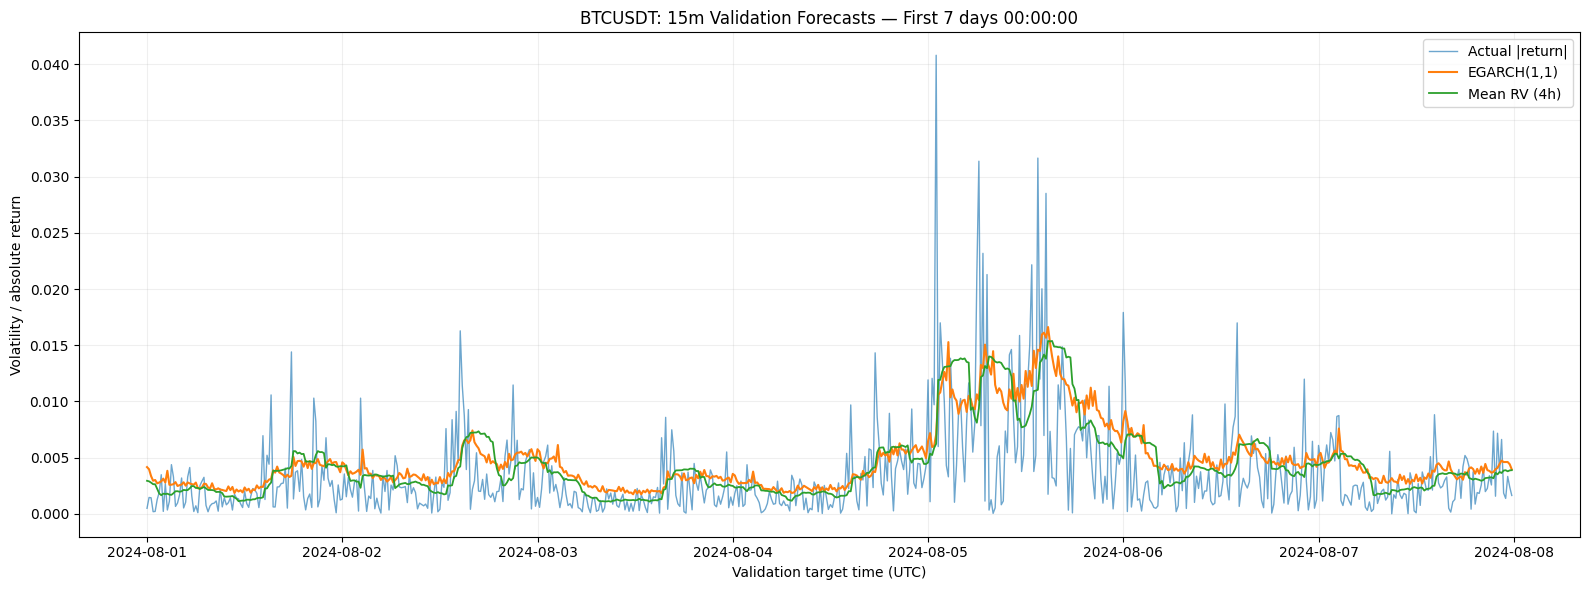

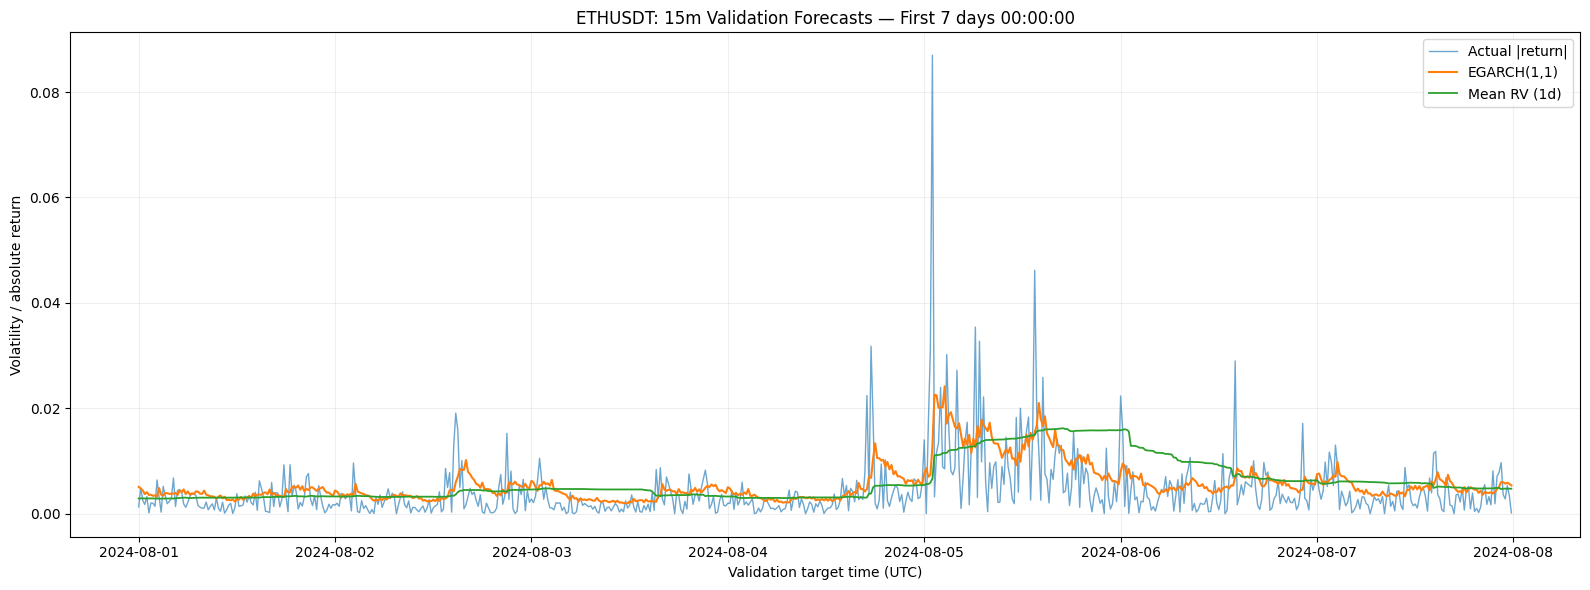

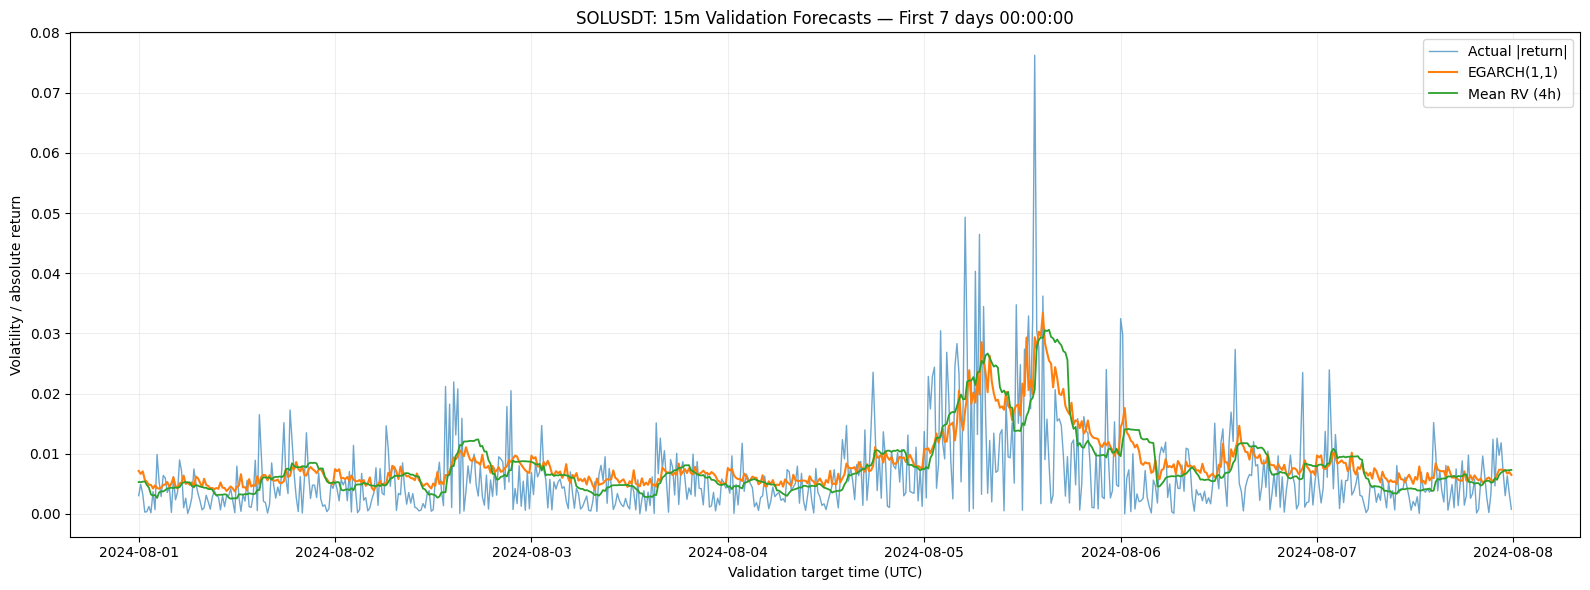

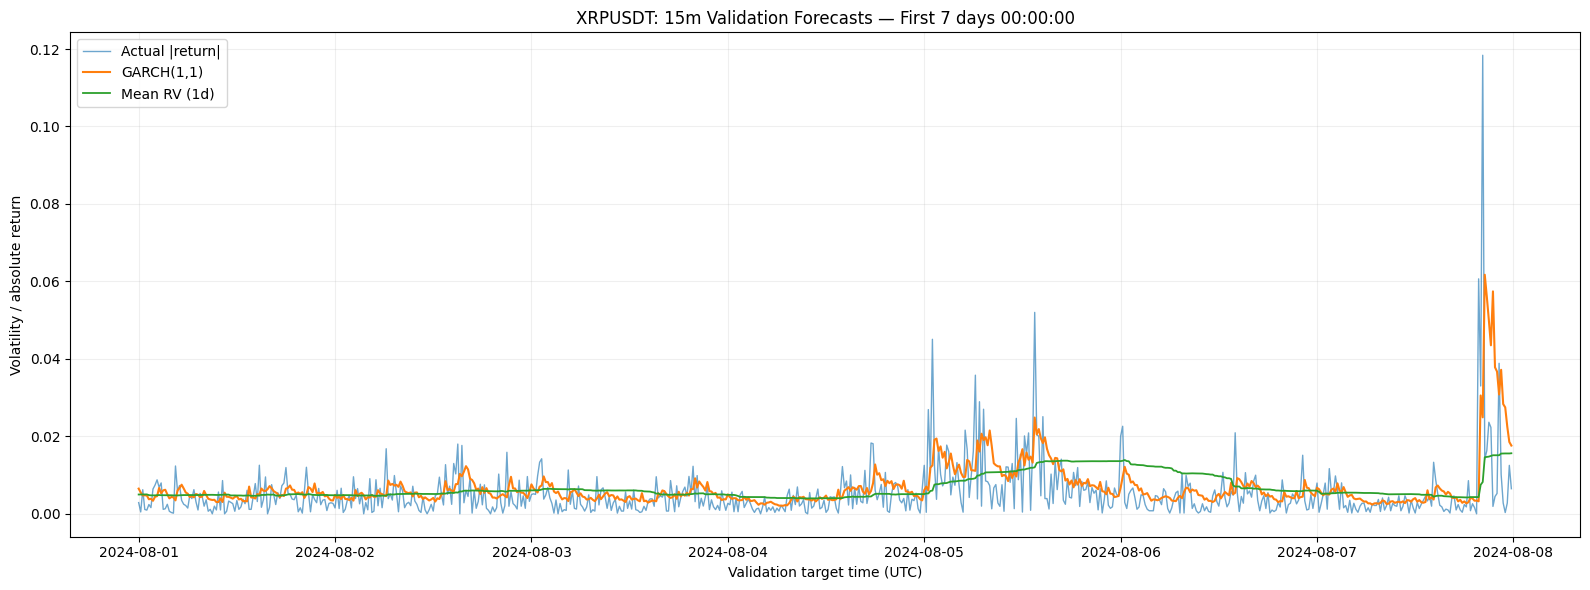

In [14]:
PLOT_WINDOW_DURATION = pd.Timedelta(
    days=7
)

plot_start = VALIDATION_START

plot_end_exclusive = (
    plot_start
    + PLOT_WINDOW_DURATION
)

for symbol in SYMBOLS:

    best_arch_model = (
        arch_metrics_df.loc[
            arch_metrics_df[
                "symbol"
            ].eq(symbol)
        ]
        .sort_values(
            "qlike"
        )
        .iloc[0][
            "model"
        ]
    )

    best_baseline_model = (
        baseline_metrics_df.loc[
            baseline_metrics_df[
                "symbol"
            ].eq(symbol)
        ]
        .sort_values(
            "qlike"
        )
        .iloc[0][
            "model"
        ]
    )

    actual = (
        canonical_validation_target.loc[
            canonical_validation_target[
                "symbol"
            ].eq(symbol)
            & canonical_validation_target[
                "target_open_time"
            ].ge(
                plot_start
            )
            & canonical_validation_target[
                "target_open_time"
            ].lt(
                plot_end_exclusive
            )
        ]
        .sort_values(
            "target_open_time"
        )
    )

    arch_plot = (
        arch_predictions_df.loc[
            arch_predictions_df[
                "symbol"
            ].eq(symbol)
            & arch_predictions_df[
                "model"
            ].eq(
                best_arch_model
            )
            & arch_predictions_df[
                "target_open_time"
            ].ge(
                plot_start
            )
            & arch_predictions_df[
                "target_open_time"
            ].lt(
                plot_end_exclusive
            )
        ]
        .sort_values(
            "target_open_time"
        )
    )

    baseline_plot = (
        baseline_metric_input.loc[
            baseline_metric_input[
                "symbol"
            ].eq(symbol)
            & baseline_metric_input[
                "model"
            ].eq(
                best_baseline_model
            )
            & baseline_metric_input[
                "target_open_time"
            ].ge(
                plot_start
            )
            & baseline_metric_input[
                "target_open_time"
            ].lt(
                plot_end_exclusive
            )
        ]
        .sort_values(
            "target_open_time"
        )
    )

    plt.figure(
        figsize=(
            16,
            6,
        )
    )

    plt.plot(
        actual[
            "target_open_time"
        ],
        np.sqrt(
            np.maximum(
                actual[
                    "canonical_target_variance"
                ],
                0.0,
            )
        ),
        label="Actual |return|",
        linewidth=1.0,
        alpha=0.65,
    )

    plt.plot(
        arch_plot[
            "target_open_time"
        ],
        np.sqrt(
            arch_plot[
                "predicted_variance"
            ]
        ),
        label=best_arch_model,
        linewidth=1.5,
    )

    plt.plot(
        baseline_plot[
            "target_open_time"
        ],
        np.sqrt(
            np.maximum(
                baseline_plot[
                    "predicted_variance"
                ],
                EPSILON,
            )
        ),
        label=best_baseline_model,
        linewidth=1.3,
    )

    plt.xlabel(
        "Validation target time (UTC)"
    )

    plt.ylabel(
        "Volatility / absolute return"
    )

    plt.title(
        f"{symbol}: {KLINE_INTERVAL} "
        f"Validation Forecasts — "
        f"First {PLOT_WINDOW_DURATION}"
    )

    plt.legend()

    plt.grid(
        alpha=0.20
    )

    plt.tight_layout()

    figure_path = (
        FIGURE_ROOT
        / (
            f"{symbol}_{KLINE_INTERVAL}_"
            "validation_example.png"
        )
    )

    plt.savefig(
        figure_path,
        dpi=200,
        bbox_inches="tight",
    )

    plt.show()

# Part E — Save outputs and final QC

## 15. Save predictions, metrics, fit diagnostics and parameters

In [15]:
BASELINE_PREDICTIONS_PATH = (
    ARCH_RESULTS_ROOT
    / "baseline_validation_predictions.parquet"
)

BASELINE_METRICS_PATH = (
    ARCH_RESULTS_ROOT
    / "baseline_validation_metrics.csv"
)

ARCH_PREDICTIONS_PATH = (
    ARCH_RESULTS_ROOT
    / "arch_validation_predictions.parquet"
)

ARCH_METRICS_PATH = (
    ARCH_RESULTS_ROOT
    / "arch_validation_metrics.csv"
)

ARCH_DIAGNOSTICS_PATH = (
    ARCH_RESULTS_ROOT
    / "arch_train_fit_diagnostics.csv"
)

ARCH_PARAMETERS_PATH = (
    ARCH_RESULTS_ROOT
    / "arch_train_parameters.csv"
)

COMBINED_METRICS_PATH = (
    ARCH_RESULTS_ROOT
    / "arch_and_baseline_validation_metrics.csv"
)

BEST_BY_ASSET_PATH = (
    ARCH_RESULTS_ROOT
    / "best_arch_or_baseline_by_asset.csv"
)


baseline_predictions_df.to_parquet(
    BASELINE_PREDICTIONS_PATH,
    index=False,
)

baseline_metrics_df.to_csv(
    BASELINE_METRICS_PATH,
    index=False,
)

arch_predictions_df.to_parquet(
    ARCH_PREDICTIONS_PATH,
    index=False,
)

arch_metrics_df.to_csv(
    ARCH_METRICS_PATH,
    index=False,
)

arch_diagnostics_df.to_csv(
    ARCH_DIAGNOSTICS_PATH,
    index=False,
)

arch_parameters_df.to_csv(
    ARCH_PARAMETERS_PATH,
    index=False,
)

combined_metrics_df.to_csv(
    COMBINED_METRICS_PATH,
    index=False,
)

best_by_asset_df.to_csv(
    BEST_BY_ASSET_PATH,
    index=False,
)


print(
    "Saved outputs:"
)

for path in [
    BASELINE_PREDICTIONS_PATH,
    BASELINE_METRICS_PATH,
    ARCH_PREDICTIONS_PATH,
    ARCH_METRICS_PATH,
    ARCH_DIAGNOSTICS_PATH,
    ARCH_PARAMETERS_PATH,
    COMBINED_METRICS_PATH,
    BEST_BY_ASSET_PATH,
]:
    print(
        " -",
        path,
    )

Saved outputs:
 - /content/drive/MyDrive/Quant Research/15min/results/15m/ARCH/baseline_validation_predictions.parquet
 - /content/drive/MyDrive/Quant Research/15min/results/15m/ARCH/baseline_validation_metrics.csv
 - /content/drive/MyDrive/Quant Research/15min/results/15m/ARCH/arch_validation_predictions.parquet
 - /content/drive/MyDrive/Quant Research/15min/results/15m/ARCH/arch_validation_metrics.csv
 - /content/drive/MyDrive/Quant Research/15min/results/15m/ARCH/arch_train_fit_diagnostics.csv
 - /content/drive/MyDrive/Quant Research/15min/results/15m/ARCH/arch_train_parameters.csv
 - /content/drive/MyDrive/Quant Research/15min/results/15m/ARCH/arch_and_baseline_validation_metrics.csv
 - /content/drive/MyDrive/Quant Research/15min/results/15m/ARCH/best_arch_or_baseline_by_asset.csv


## 16. Final end-to-end QC

In [16]:
# ------------------------------------------------------------
# Test must not appear anywhere in evaluated prediction files.
# ------------------------------------------------------------

assert (
    arch_predictions_df[
        "target_open_time"
    ]
    .lt(
        TEST_START
    )
    .all()
)

assert (
    baseline_predictions_df[
        "target_open_time"
    ]
    .lt(
        TEST_START
    )
    .all()
)


# ------------------------------------------------------------
# Complete validation coverage and identical target dates.
# ------------------------------------------------------------

canonical_date_sets = {
    symbol: set(
        validation_rows_df.loc[
            validation_rows_df[
                "symbol"
            ].eq(symbol),
            "target_open_time",
        ]
    )
    for symbol in SYMBOLS
}

for symbol in SYMBOLS:

    expected_dates = (
        canonical_date_sets[
            symbol
        ]
    )

    if (
        len(
            expected_dates
        )
        != EXPECTED_VALIDATION_ROWS
    ):
        raise ValueError(
            f"{symbol}: unexpected canonical "
            "validation date count."
        )

    for model_name in (
        arch_predictions_df.loc[
            arch_predictions_df[
                "symbol"
            ].eq(symbol),
            "model",
        ]
        .unique()
    ):

        model_dates = set(
            arch_predictions_df.loc[
                arch_predictions_df[
                    "symbol"
                ].eq(symbol)
                & arch_predictions_df[
                    "model"
                ].eq(
                    model_name
                ),
                "target_open_time",
            ]
        )

        assert (
            model_dates
            == expected_dates
        )

    for model_name in (
        baseline_predictions_df.loc[
            baseline_predictions_df[
                "symbol"
            ].eq(symbol),
            "model",
        ]
        .unique()
    ):

        model_dates = set(
            baseline_predictions_df.loc[
                baseline_predictions_df[
                    "symbol"
                ].eq(symbol)
                & baseline_predictions_df[
                    "model"
                ].eq(
                    model_name
                ),
                "target_open_time",
            ]
        )

        assert (
            model_dates
            == expected_dates
        )


# ------------------------------------------------------------
# Finite / positive predictions.
# ------------------------------------------------------------

assert np.isfinite(
    arch_predictions_df[
        "predicted_variance"
    ]
    .to_numpy(
        dtype=float
    )
).all()

assert (
    arch_predictions_df[
        "predicted_variance"
    ]
    .gt(0)
    .all()
)

assert np.isfinite(
    baseline_predictions_df[
        "predicted_variance"
    ]
    .to_numpy(
        dtype=float
    )
).all()

assert (
    baseline_predictions_df[
        "predicted_variance"
    ]
    .ge(0)
    .all()
)


# ------------------------------------------------------------
# Metrics finite and QLIKE non-negative.
# ------------------------------------------------------------

for metric_df in [
    baseline_metrics_df,
    arch_metrics_df,
]:

    assert np.isfinite(
        metric_df[
            [
                "mae",
                "rmse",
                "qlike",
            ]
        ]
        .to_numpy(
            dtype=float
        )
    ).all()

    assert (
        metric_df[
            "qlike"
        ]
        .ge(
            -1e-12
        )
        .all()
    )


# ------------------------------------------------------------
# Saved artifacts reload successfully.
# ------------------------------------------------------------

reloaded_arch_predictions = (
    pd.read_parquet(
        ARCH_PREDICTIONS_PATH
    )
)

reloaded_baseline_predictions = (
    pd.read_parquet(
        BASELINE_PREDICTIONS_PATH
    )
)

assert (
    len(
        reloaded_arch_predictions
    )
    == len(
        arch_predictions_df
    )
)

assert (
    len(
        reloaded_baseline_predictions
    )
    == len(
        baseline_predictions_df
    )
)


print(
    "ALL INTRADAY BASELINE / ARCH "
    "VALIDATION QC CHECKS PASSED."
)

print(
    "\nTest period remains untouched."
)

print(
    "\nNext notebook:"
)

print(
    "04_Intraday_DL_Lookback_Selection.ipynb"
)

ALL INTRADAY BASELINE / ARCH VALIDATION QC CHECKS PASSED.

Test period remains untouched.

Next notebook:
04_Intraday_DL_Lookback_Selection.ipynb


# What carries forward

After this notebook:

1. the simple predictive baselines are fixed;
2. GARCH(1,1), GJR-GARCH(1,1) and EGARCH(1,1) have been compared on Validation;
3. all ARCH models account for training-estimated intraday clock seasonality;
4. Test remains untouched;
5. the next step is to train MLP / GRU / LSTM across the duration-based candidate sequence histories frozen in Notebook 02.

Notebook 04 should select each DL architecture's sequence duration on Validation, exactly as the earlier daily project selected architecture-specific lookbacks rather than forcing one common duration across fundamentally different model classes.